# 18b: the block basis on two archives

Notebook 18a measured the block basis on synthetic records. The same four
adaptations are measured here on data nobody generated, and the closing
section collects both notebooks' exported tables into one map of where the
block basis is ahead, needed, at parity and behind.

1. On real GPS station series with the epochs of a published step database
   known, moving a window edge onto each epoch recovers the shift estimates
   of the pointwise fit at a coefficient count that carries the smooth part
   of the model, where the plain Legendre and uniform block images at the
   same K do not, and it does so with a Gram that stays conditioned.
   False if block on epochs is not closer to the pointwise shifts than
   Legendre is, or if its Gram is as badly conditioned.
2. With the epochs unknown, `fit_aligned` finds a small set of them, and
   self-scaling the detection statistic is what keeps that set small: it
   cuts the count a station and raises the share of it that lands on a
   database epoch, and most of what it finds still does not. False if
   self-scaling does not cut the detection count or does not raise that
   share. The velocity the two routes that share those detections report
   is then the same to within a hundredth of a millimetre a year at the
   median station, in the window image or pointwise: on this archive the
   basis is not what decides the answer, detection is. False if those two
   routes separate on the stations at large.
3. Hourly temperature reduced to 3 h and 6 h means is a record that arrives
   aggregated. The area fit recovers the diurnal and semidiurnal amplitudes
   of the hourly fit, while reading the means at the window midpoints loses
   most of what the sinc factor of the window width predicts. False if the
   area ratios are not near one, or if the midpoint ratios do not sit near
   the sinc.
4. The map built from the two notebooks' CSV files carries all four
   verdicts. False if one of them has no measured row behind it.

The GPS archive is the Nevada Geodetic Laboratory copy under
`$SHOWCASE_DATA/ngl` (daily `tenv3` positions, the step database and the
MIDAS velocities); the temperature archive is the NOAA Integrated Surface
Database copy of 2024 under `$SHOWCASE_ISD`. Neither is fetched by
`study.download_data`, and each of the first three sections skips with a
visible message when its archive is absent. The map section reads the
tracked CSV files and runs either way.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import dtfit
from dtfit.image import Original
from dtfit.image.bases import u_of
from dtfit_experimental import EdgeBlockBasis, SegmentBasis, fit_aggregated, fit_aligned
from dtfit_experimental.study import isd, montecarlo, ngl, notebook, paths

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

NGL_DIR = paths.ngl_dir()
ISD_DIR = paths.isd_dir(2024)
NGL_STEPS = notebook.data_file("steps.txt", root=NGL_DIR)
NGL_TENV3 = notebook.data_file("tenv3", root=NGL_DIR)
NGL_MIDAS = notebook.data_file("midas.IGS20.txt", root=NGL_DIR)
ISD_YEAR = notebook.data_file(root=ISD_DIR)
HAVE_NGL = None not in (NGL_STEPS, NGL_TENV3, NGL_MIDAS)

N_NGL = 12 if QUICK else 120
N_ISD = 10 if QUICK else 150
YEAR_DAYS = 365.25
# every selected epoch keeps 200 days clear of the record ends and of the
# next epoch, and a detection within 21 days of a database date is a match
GUARD = 200.0 / YEAR_DAYS
TOL = 21.0 / YEAR_DAYS
NAMES = ["a", "v", "s1", "c1", "s2", "c2"]
print(f"QUICK={QUICK} stations: {N_NGL} NGL, {N_ISD} ISD")

QUICK=False stations: 120 NGL, 150 ISD


## 1. GPS series with the epochs known

The trajectory model of a daily GPS position series is an offset, a linear
velocity, an annual and a semiannual cycle, and one level shift per epoch
of the step database that falls inside the record. Time is the decimal year
`ngl.read_tenv3` returns, with the station's first epoch as the origin, and
the observable is its relative east coordinate.

A station is selected when it has at least 2500 samples over at least 8
years, 1 to 6 database steps inside the record that stay 200 days clear of
its ends and of each other, and at least 60 samples in the 200 days on
each side of every one of them. The stations are taken in a seeded shuffle
of the archive, so the selection is a sample of what the archive holds and
not a hand-picked set.

In [2]:
def design(t, epochs):
    """Offset, velocity, annual, semiannual and one level shift per epoch."""
    w = 2 * np.pi
    cols = [np.ones_like(t), t, np.sin(w * t), np.cos(w * t),
            np.sin(2 * w * t), np.cos(2 * w * t)]
    cols += [(t >= e).astype(float) for e in epochs]
    return np.stack(cols, axis=1)


def model_of(epochs):
    def f(x, *p):
        return design(np.asarray(x, float), epochs) @ np.asarray(p, float)

    return f


def select_ngl(n_want):
    steps = ngl.read_steps(NGL_STEPS)
    files = ngl.station_files(NGL_TENV3)
    rng = np.random.default_rng(0)
    out = []
    for i in rng.permutation(len(files)):
        if len(out) >= n_want:
            break
        path = files[i]
        sta = path.stem
        if sta not in steps:
            continue
        try:
            chunks = list(ngl.read_tenv3(path))
        except (OSError, ValueError):
            # one unreadable station file must not stop the scan
            continue
        if not chunks:
            continue
        t = np.concatenate([c.t for c in chunks])
        y = np.concatenate([c.east for c in chunks])
        if t.size < 2500 or (t[-1] - t[0]) < 8.0:
            continue
        ep = sorted(s.year for s in steps[sta] if t[0] + GUARD < s.year < t[-1] - GUARD)
        ep = [v for j, v in enumerate(ep) if j == 0 or v - ep[j - 1] > GUARD]
        if not 1 <= len(ep) <= 6:
            continue
        if any(((t >= v - GUARD) & (t < v)).sum() < 60
               or ((t >= v) & (t < v + GUARD)).sum() < 60 for v in ep):
            continue
        out.append({"sta": sta, "t0": float(t[0]), "t": t - t[0],
                    "y": y - np.median(y), "epochs": [v - t[0] for v in ep],
                    "database": np.array([s.year for s in steps[sta]]) - t[0]})
    return out


if HAVE_NGL:
    stations = select_ngl(N_NGL)
    # the pointwise least squares every basis is measured against, and the
    # standard error the distances below are in units of
    for s in stations:
        j = design(s["t"], s["epochs"])
        cov = np.linalg.inv(j.T @ j)
        c = cov @ (j.T @ s["y"])
        s2 = np.sum((s["y"] - j @ c) ** 2) / (s["t"].size - j.shape[1])
        s["ref"] = c
        s["se"] = np.sqrt(s2 * np.diag(cov))
        s["v_nostep"] = float(np.linalg.lstsq(design(s["t"], []), s["y"], rcond=None)[0][1])
    spans = np.array([s["t"][-1] for s in stations])
    print(f"{len(stations)} stations, span {spans.min():.1f} to {spans.max():.1f} years "
          f"(median {np.median(spans):.1f}), "
          f"{sum(len(s['epochs']) for s in stations)} database epochs inside the records")
else:
    stations = []
    print("no NGL archive, skipping sections 1 and 2")

120 stations, span 8.6 to 32.6 years (median 16.0), 278 database epochs inside the records


In [3]:
def edge_block_on(k, epochs, dom):
    """K uniform windows with the edge nearest each epoch moved onto it."""
    edges = np.linspace(dom[0], dom[1], k + 1)
    for e in epochs:
        i = 1 + int(np.argmin(np.abs(edges[1:-1] - e)))
        edges[i] = e
    return EdgeBlockBasis.on(np.unique(edges), dom)


rows = []
for s in stations:
    t, y, ep = s["t"], s["y"], s["epochs"]
    dom = (0.0, float(t[-1]))
    names = NAMES + [f"step_{i + 1}" for i in range(len(ep))]
    f = model_of(ep)
    j = design(t, ep)
    orig = Original(t, y, domain=dom)
    for k_per_year in (8, 4):
        k = int(round(k_per_year * dom[1]))
        bases = {
            "Legendre": ("legendre", k),
            "block": ("block", k),
            "block on epochs": (edge_block_on(k, ep, dom), None),
            "segment": (SegmentBasis.on([dom[0], *ep, dom[1]], dom, k), None),
        }
        for label, (basis, order) in bases.items():
            with warnings.catch_warnings():
                # the Legendre image warns about coverage at these orders on
                # a stepped model, once a station and K; the reading of that
                # warning is section 4 of notebook 18a
                warnings.simplefilter("ignore")
                r = dtfit.fit(f, orig, basis=basis, order=order,
                              p0=np.zeros(len(names)), param_names=names)
                eff = montecarlo.image_efficiency(j, t, basis=basis, order=order,
                                                  domain=dom)
            c = np.asarray(r.coeffs, float)
            seg_cond = float("nan")
            if label == "segment":
                # the whole Gram of unequal segments carries the ratio of
                # their sample counts too, so the largest of the per-segment
                # blocks is reported beside it
                phi = basis.evaluate(u_of(t, *dom))
                cuts = np.concatenate([[0], np.cumsum(basis.orders + 1)])
                seg_cond = max(
                    float(np.linalg.cond(phi[:, lo:hi].T @ phi[:, lo:hi]))
                    for lo, hi in zip(cuts[:-1], cuts[1:]))
            rows.append({
                "station": s["sta"], "K_per_year": k_per_year, "basis": label,
                "shift_dist": float(np.max(np.abs(c[6:] - s["ref"][6:]) / s["se"][6:])),
                "vel_dist": float(abs(c[1] - s["ref"][1]) / s["se"][1]),
                "cond": eff.cond, "cond_segments_max": seg_cond,
                "n_coef": eff.n_coef, "rank": eff.rank,
            })
known_stations = pd.DataFrame(rows)
if not known_stations.empty:
    ngl_known_epochs = known_stations.groupby(["K_per_year", "basis"]).agg(
        stations=("station", "size"),
        shift_dist_med=("shift_dist", "median"),
        shift_dist_p90=("shift_dist", lambda v: np.percentile(v, 90)),
        vel_dist_med=("vel_dist", "median"),
        vel_dist_p90=("vel_dist", lambda v: np.percentile(v, 90)),
        cond_med=("cond", "median"), cond_max=("cond", "max"),
        cond_segments_max=("cond_segments_max", "max"),
        n_coef_med=("n_coef", "median"), rank_med=("rank", "median"),
    ).reset_index()
else:
    ngl_known_epochs = pd.DataFrame()
ngl_known_epochs

,K_per_year,basis,stations,shift_dist_med,shift_dist_p90,vel_dist_med,vel_dist_p90,cond_med,cond_max,cond_segments_max,n_coef_med,rank_med
0,4,Legendre,120,0.801292,2.403689,0.469450,1.605065,220.631421,1.011117e+17,NaN,65.5,65.5
1,4,block,120,0.992107,2.196212,0.452431,1.583876,2.139535,9.300000e+01,NaN,63.0,63.0
2,4,block on epochs,120,0.415279,1.502142,0.213441,0.955428,3.119115,1.300000e+02,NaN,63.0,63.0
3,4,segment,120,0.158096,0.479442,0.103716,0.372241,201.497014,5.239170e+16,5.152369e+16,64.5,64.5
4,8,Legendre,120,0.392845,1.120226,0.237927,0.831245,1612.986511,9.769261e+18,NaN,129.5,129.5
5,8,block,120,0.435061,1.448307,0.237394,0.912173,3.685897,4.600000e+01,NaN,126.0,126.0
6,8,block on epochs,120,0.032343,0.099252,0.025410,0.092980,5.055556,6.800000e+01,NaN,126.0,126.0
7,8,segment,120,0.000416,0.003673,0.000191,0.001825,5217.340046,3.035597e+18,2.930660e+18,128.5,128.5


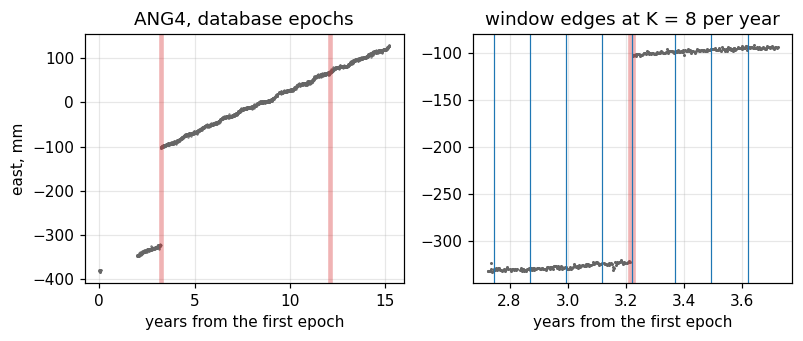

In [4]:
if stations:
    # the station carrying the most significant database shift of the sample
    def significance(s):
        return np.abs(s["ref"][6:]) / s["se"][6:]

    pick = max(stations, key=lambda s: np.max(significance(s)))
    epoch = float(pick["epochs"][int(np.argmax(significance(pick)))])
    dom_pick = (0.0, float(pick["t"][-1]))
    k_pick = int(round(8 * dom_pick[1]))
    edges_pick = edge_block_on(k_pick, pick["epochs"], dom_pick).edges_on(dom_pick)
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
    axes[0].plot(pick["t"], 1e3 * pick["y"], ".", ms=1.0, color="0.4")
    for e in pick["epochs"]:
        axes[0].axvline(e, color="tab:red", lw=3.0, alpha=0.35)
    axes[0].set_xlabel("years from the first epoch")
    axes[0].set_ylabel("east, mm")
    axes[0].set_title(f"{pick['sta']}, database epochs")
    near = np.abs(pick["t"] - epoch) < 0.5
    axes[1].plot(pick["t"][near], 1e3 * pick["y"][near], ".", ms=2.0, color="0.4")
    axes[1].axvline(epoch, color="tab:red", lw=5.0, alpha=0.35)
    for e in edges_pick[np.abs(edges_pick - epoch) < 0.5]:
        axes[1].axvline(e, color="tab:blue", lw=0.8)
    axes[1].set_xlabel("years from the first epoch")
    axes[1].set_title("window edges at K = 8 per year")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.tight_layout()
else:
    print("no NGL archive, no figure")

In [5]:
if not ngl_known_epochs.empty:
    at8 = ngl_known_epochs[ngl_known_epochs.K_per_year == 8].set_index("basis")
    at4 = ngl_known_epochs[ngl_known_epochs.K_per_year == 4].set_index("basis")
    block_cond = ngl_known_epochs[
        ngl_known_epochs.basis.isin(["block", "block on epochs"])].cond_max.max()
    # fails if a window edge on the database epoch does not recover the
    # pointwise shifts to within a tenth of their standard error at K = 8
    assert at8.loc["block on epochs", "shift_dist_med"] < 0.1
    # fails if it is not at most a third of the distance the Legendre image
    # at the same K leaves
    assert (at8.loc["block on epochs", "shift_dist_med"]
            < at8.loc["Legendre", "shift_dist_med"] / 3)
    # fails if either block Gram stops being well conditioned at either K
    assert block_cond < 1e3
    # fails if the Legendre Gram is not driven singular on some station
    assert at8.loc["Legendre", "cond_max"] > 1e17
    print(f"at K = 8 per year: block on epochs "
          f"{at8.loc['block on epochs', 'shift_dist_med']:.3f} standard errors from the "
          f"pointwise shifts at the median, Legendre "
          f"{at8.loc['Legendre', 'shift_dist_med']:.3f}, uniform block "
          f"{at8.loc['block', 'shift_dist_med']:.3f}, segment "
          f"{at8.loc['segment', 'shift_dist_med']:.3f}")
    print(f"at K = 4 per year the same four are "
          f"{at4.loc['block on epochs', 'shift_dist_med']:.3f}, "
          f"{at4.loc['Legendre', 'shift_dist_med']:.3f}, "
          f"{at4.loc['block', 'shift_dist_med']:.3f} and "
          f"{at4.loc['segment', 'shift_dist_med']:.3f}")
    print(f"worst block cond(G) {block_cond:.0f}; worst Legendre cond(G) "
          f"{at8.loc['Legendre', 'cond_max']:.1e} at K = 8 and "
          f"{at4.loc['Legendre', 'cond_max']:.1e} at K = 4; worst segment cond(G) "
          f"{at8.loc['segment', 'cond_max']:.1e} and {at4.loc['segment', 'cond_max']:.1e} "
          f"over the whole basis, whose largest single segment is "
          f"{at8.loc['segment', 'cond_segments_max']:.1e} and "
          f"{at4.loc['segment', 'cond_segments_max']:.1e}")
else:
    print("no NGL archive, nothing to check")

at K = 8 per year: block on epochs 0.032 standard errors from the pointwise shifts at the median, Legendre 0.393, uniform block 0.435, segment 0.000
at K = 4 per year the same four are 0.415, 0.801, 0.992 and 0.158
worst block cond(G) 130; worst Legendre cond(G) 9.8e+18 at K = 8 and 1.0e+17 at K = 4; worst segment cond(G) 3.0e+18 and 5.2e+16 over the whole basis, whose largest single segment is 2.9e+18 and 5.2e+16


At 8 windows a year the placement of the edges is the whole difference. A
window boundary on every database epoch leaves the shift estimates 0.032
standard errors from the pointwise ones at the median and 0.099 at the 90th
percentile, and the velocity 0.025; the Legendre image at the same K
leaves 0.393 and 1.120, uniform windows 0.435 and 1.448. The coefficient
counts are close and not equal: a Legendre image of order K holds K + 1
coefficients, a median of 129.5 over the stations, and a block image drops
the windows a station's gaps leave empty, a median of 126; at 4 windows a
year the two medians are 65.5 and 63. Uniform windows are not the better of
the two plain images here - at both K the Legendre median is the smaller of
them - and the uniform block basis differs from block on epochs in nothing
but where its boundaries fall.

At 4 windows a year every basis loses. Block on epochs is 0.415 standard
errors away at the median, against 0.801 for Legendre and 0.992 for uniform
windows: 91-day windows cannot carry the annual cycle the model contains,
so a boundary on the epoch is not enough to recover the pointwise answer.
The claim holds at 8 windows a year, not at any window count.

The Gram matrices separate the same way they did on the synthetic burst
grids. Neither block basis exceeds cond(G) 130 at either K on any of the
120 stations, while the Legendre one reaches 9.8e18 at 8 windows a year
and 1.0e17 at 4, with a median of 1613 at 8. The segment basis is the most
accurate of the four, 0.0004 standard errors at the median and 0.0037 at
the 90th percentile, and it inherits that conditioning: its whole-basis
cond(G) reaches 3.0e18, of which the largest single segment contributes
2.9e18, so the number is one segment's own Legendre Gram and not the ratio
of the segments' sample counts. On these records the near-singular solve
did not damage the estimates, which is what 18a measured on its burst grids
over repeated draws: an image whose Gram is past 1e12 stayed within 0.3
percent of the pointwise fit there.

The figure is one of the 120 stations, the one carrying the most
significant database shift: its whole east series with the database epochs
marked as a red band, and a zoom around that shift with the window edges
of the block-on-epochs basis at 8 windows a year drawn over it. The edge
that was moved is the blue line inside the band; its neighbours keep the
uniform spacing.

In [6]:
if QUICK or ngl_known_epochs.empty:
    print("QUICK or no archive: skipping the CSV export")
else:
    notebook.save_table("18b_block_basis_real_data", "ngl_known_epochs", ngl_known_epochs)
    print("wrote experiments/results/18b_block_basis_real_data/ngl_known_epochs.csv")

wrote experiments/results/18b_block_basis_real_data/ngl_known_epochs.csv


## 2. The same series with the epochs unknown

`fit_aligned` sees only the record and the smooth part of the model: it
images the residual on fine windows of about 7 days, tests each of them for
a level jump, re-cuts the coarse windows onto whatever it finds and refits
with the windows holding an epoch left out. The step database is used for
scoring only.

Two detector settings are crossed with self-scaling, which divides the
detection statistic by its own robust spread and so answers coloured noise
rather than the white noise the plain statistic assumes. Each cell is
scored against the database (how many of the large steps it finds, how many
of all of them, how many detections a station it makes and what fraction of
them land on a database date) and by the east velocity each route then
reports, against the published MIDAS velocity and against the fit that was
given the database epochs. A database step counts as large when the
pointwise fit of section 1 puts its shift at 3 mm or more and at 5 or more
of its own standard errors.

In [7]:
FINE_DAYS = 7.0
K_PER_YEAR = 8
# fine windows of about FINE_DAYS days at K_PER_YEAR coarse windows a year
FINE = max(1, int(round(YEAR_DAYS / (K_PER_YEAR * FINE_DAYS))))
SETTINGS = [(8, 5.0), (26, 4.0)]
# a database step is large at 3 mm and 5 standard errors of the pointwise fit
LARGE_M = 0.003
LARGE_SE = 5.0

midas = ngl.read_midas(NGL_MIDAS) if HAVE_NGL else {}
det_rows, vel_rows = [], []
if not stations:
    print("no NGL archive, skipping section 2")
for span, threshold in SETTINGS if stations else []:
    for self_scale in (True, False):
        n_db = n_hit = n_big = n_big_hit = n_det = n_match = n_dropped = 0
        n_flagged = 0
        for s in stations:
            t, y, ep = s["t"], s["y"], s["epochs"]
            dom = (0.0, float(t[-1]))
            k = int(round(K_PER_YEAR * dom[1]))
            with warnings.catch_warnings():
                # a station whose detected epochs leave a window with too
                # few samples warns out of the least-squares solve
                warnings.simplefilter("ignore")
                fit = fit_aligned(model_of([]), Original(t, y, domain=dom), n_windows=k,
                                  fine=FINE, span=span, threshold=threshold, n_min=3,
                                  self_scale=self_scale, clip=5.0, max_iter=8,
                                  p0=np.zeros(len(NAMES)), param_names=NAMES)
            det = np.asarray(fit.epochs, float)
            se = s["se"][6:]
            big = (np.abs(s["ref"][6:]) >= LARGE_M) & (np.abs(s["ref"][6:]) >= LARGE_SE * se)
            hit = np.array([det.size > 0 and np.min(np.abs(det - e)) <= TOL for e in ep])
            n_db += hit.size
            n_hit += int(hit.sum())
            n_big += int(big.sum())
            n_big_hit += int((hit & big).sum())
            n_det += det.size
            n_match += int(sum(np.min(np.abs(s["database"] - x)) <= TOL for x in det))
            n_dropped += fit.n_dropped
            n_flagged += fit.flagged.size
            if s["sta"] in midas:
                v_det = float(np.linalg.lstsq(design(t, sorted(det)), y,
                                              rcond=None)[0][1])
                target = 1e3 * midas[s["sta"]].ve
                for name, v in (("pointwise, database epochs", s["ref"][1]),
                                ("pointwise, no steps", s["v_nostep"]),
                                ("pointwise, detected epochs", v_det),
                                ("aligned", float(fit.result.coeffs[1]))):
                    vel_rows.append({
                        "span": span, "threshold": threshold, "self_scale": self_scale,
                        "station": s["sta"], "estimator": name, "v_mm_yr": 1e3 * v,
                        "d_midas_mm_yr": abs(1e3 * v - target),
                        "d_ref_mm_yr": abs(1e3 * (v - s["ref"][1]))})
        det_rows.append({
            "span": span, "threshold": threshold, "self_scale": self_scale,
            "stations": len(stations), "large_steps": n_big,
            "large_found": n_big_hit / max(n_big, 1),
            "database_steps": n_db, "all_found": n_hit / max(n_db, 1),
            "det_per_station": n_det / max(len(stations), 1),
            "at_database_epoch": n_match / max(n_det, 1),
            "flagged_windows": n_flagged, "clipped_samples": n_dropped})
ngl_detection = pd.DataFrame(det_rows)
ngl_velocity_station = pd.DataFrame(vel_rows)
ngl_velocity = ngl_velocity_station
if not ngl_velocity.empty:
    ngl_velocity = ngl_velocity_station.groupby(
        ["span", "threshold", "self_scale", "estimator"]).agg(
        stations=("d_midas_mm_yr", "size"),
        d_midas_med=("d_midas_mm_yr", "median"),
        d_midas_p90=("d_midas_mm_yr", lambda v: np.percentile(v, 90)),
        d_ref_med=("d_ref_mm_yr", "median"),
        d_ref_p90=("d_ref_mm_yr", lambda v: np.percentile(v, 90)),
    ).reset_index()
ngl_detection

,span,threshold,self_scale,stations,large_steps,large_found,database_steps,all_found,det_per_station,at_database_epoch,flagged_windows,clipped_samples
0,8,5.0,True,120,92,0.184783,278,0.064748,1.491667,0.156425,179,4166
1,8,5.0,False,120,92,0.423913,278,0.187050,9.191667,0.065277,1103,4166
2,26,4.0,True,120,92,0.315217,278,0.104317,1.425000,0.269006,171,4166
3,26,4.0,False,120,92,0.706522,278,0.460432,47.958333,0.031972,5755,4166


In [8]:
ngl_velocity

,span,threshold,self_scale,estimator,stations,d_midas_med,d_midas_p90,d_ref_med,d_ref_p90
0,8,5.0,False,aligned,120,0.148027,0.724397,0.185548,1.370895
1,8,5.0,False,"pointwise, database epochs",120,0.088447,0.918012,0.000000,0.000000
2,8,5.0,False,"pointwise, detected epochs",120,0.146347,0.760621,0.174544,1.334104
3,8,5.0,False,"pointwise, no steps",120,0.180005,1.503872,0.152744,1.378253
4,8,5.0,True,aligned,120,0.141521,0.588079,0.141294,1.141944
5,8,5.0,True,"pointwise, database epochs",120,0.088447,0.918012,0.000000,0.000000
6,8,5.0,True,"pointwise, detected epochs",120,0.147438,0.645822,0.140572,1.193997
7,8,5.0,True,"pointwise, no steps",120,0.180005,1.503872,0.152744,1.378253
8,26,4.0,False,aligned,120,0.289994,1.658118,0.402776,3.009988
9,26,4.0,False,"pointwise, database epochs",120,0.088447,0.918012,0.000000,0.000000


In [9]:
if not ngl_detection.empty:
    det = ngl_detection.set_index(["span", "threshold", "self_scale"])
    vel = ngl_velocity.set_index(["span", "threshold", "self_scale", "estimator"])
    gaps = {}
    for span, threshold in SETTINGS:
        on = det.loc[(span, threshold, True)]
        off = det.loc[(span, threshold, False)]
        # fails if self-scaling does not cut the detections a station by at
        # least a factor three at the same span and threshold
        assert on.det_per_station * 3 <= off.det_per_station
        # fails if it does not raise the fraction of detections that land on
        # a database date
        assert on.at_database_epoch > off.at_database_epoch
        # fails if the two routes that work from the same self-scaled
        # detections separate, station by station, by more than a twentieth
        # of a millimetre a year at the 90th percentile of the stations
        per = ngl_velocity_station[
            (ngl_velocity_station.span == span)
            & (ngl_velocity_station.threshold == threshold)
            & ngl_velocity_station.self_scale].pivot(
            index="station", columns="estimator", values="v_mm_yr")
        gap = (per["aligned"] - per["pointwise, detected epochs"]).abs()
        gaps[(span, threshold)] = gap
        assert np.percentile(gap, 90) < 0.05
        # fails if the medians those two routes report against MIDAS
        # separate by more than a hundredth of a millimetre a year
        pair = vel.loc[(span, threshold, True)]
        assert abs(pair.loc["aligned", "d_midas_med"]
                   - pair.loc["pointwise, detected epochs", "d_midas_med"]) < 0.01
        # fails if detecting the epochs does not beat ignoring them, in the
        # self-scaled cell; the non-self-scaled cells are read below
        on_vel = vel.loc[(span, threshold, True)]
        assert on_vel.loc["aligned", "d_midas_med"] < on_vel.loc[
            "pointwise, no steps", "d_midas_med"]
    print("detections a station, self-scaled against not:",
          [(f"span {s}, threshold {t:g}",
            round(float(det.loc[(s, t, True)].det_per_station), 2),
            round(float(det.loc[(s, t, False)].det_per_station), 2))
           for s, t in SETTINGS])
    print("fraction of detections at a database epoch:",
          [(f"span {s}, threshold {t:g}",
            round(float(det.loc[(s, t, True)].at_database_epoch), 3),
            round(float(det.loc[(s, t, False)].at_database_epoch), 3))
           for s, t in SETTINGS])
    print("large database steps found, self-scaled:",
          [(f"span {s}, threshold {t:g}",
            round(float(det.loc[(s, t, True)].large_found), 3))
           for s, t in SETTINGS])
    print("median |v - MIDAS| in mm/yr, span 8 threshold 5, self-scaled:",
          vel.loc[(8, 5.0, True)].d_midas_med.round(3).to_dict())
    for (s, t), g in gaps.items():
        print(f"span {s}, threshold {t:g}: per-station |v aligned - v pointwise on "
              f"the same detections| in mm/yr, median {np.median(g):.4f}, 90th "
              f"percentile {np.percentile(g, 90):.4f}, {int((g > 0.1).sum())} of "
              f"{g.size} stations over 0.1, largest {g.max():.0f}")
else:
    print("no NGL archive, nothing to check")

detections a station, self-scaled against not: [('span 8, threshold 5', 1.49, 9.19), ('span 26, threshold 4', 1.43, 47.96)]
fraction of detections at a database epoch: [('span 8, threshold 5', 0.156, 0.065), ('span 26, threshold 4', 0.269, 0.032)]
large database steps found, self-scaled: [('span 8, threshold 5', 0.185), ('span 26, threshold 4', 0.315)]
median |v - MIDAS| in mm/yr, span 8 threshold 5, self-scaled: {'aligned': 0.142, 'pointwise, database epochs': 0.088, 'pointwise, detected epochs': 0.147, 'pointwise, no steps': 0.18}
span 8, threshold 5: per-station |v aligned - v pointwise on the same detections| in mm/yr, median 0.0008, 90th percentile 0.0110, 3 of 120 stations over 0.1, largest 156
span 26, threshold 4: per-station |v aligned - v pointwise on the same detections| in mm/yr, median 0.0009, 90th percentile 0.0096, 3 of 120 stations over 0.1, largest 203


Self-scaling is what makes the detector usable on this archive. At span 8
and threshold 5 it cuts the detections from 9.19 a station to 1.49 and
raises the fraction that land within 21 days of a database date from 0.065
to 0.156; at span 26 and threshold 4, from 47.96 to 1.43 and from 0.032 to
0.269. It pays in recall: of the 92 database steps that are large, out of
278, the self-scaled detector finds 18 and 32 percent at the two settings,
against 42 and 71 percent without it. Neither setting is a good detector of
this database.
A daily east series is strongly autocorrelated and most of its catalogued
steps are small beside that correlation, so detection, not the basis, is
the limit on everything below.

The velocity shows where that limit falls. The fit handed the database
epochs is 0.088 mm/yr from the published MIDAS velocity at the median, and
ignoring steps altogether costs 0.180. The self-scaled routes recover part
of the difference: 0.142 at span 8 and threshold 5, and 0.100 at span 26
and threshold 4, which is within 0.012 mm/yr of the fit that was given the
epochs. Without self-scaling, span 26 and threshold 4 detects 48 epochs a
station and lands at 0.290, worse than not modelling any step at all.

Whether the model is then fitted in the aligned window image or pointwise
on the same detected epochs makes no difference worth reporting on the
station the reader will meet. The two velocities are 0.0008 mm/yr apart at
the median station at span 8 and threshold 5 and 0.0009 at span 26 and
threshold 4, 0.011 and 0.010 apart at the 90th percentile of the 120
stations, and the two medians against MIDAS differ by 0.006 mm/yr and by
0.0003. Three stations at each setting sit outside that picture: there the
pointwise refit on the detected epochs returns a velocity between 0.15 and
203 mm/yr from the aligned one. So it is parity on the archive and not a
guarantee a station, and with the epochs fixed there is nothing here for a
basis to win - 8 windows a year carry the smooth part of the model either
way.

In [10]:
if QUICK or ngl_detection.empty:
    print("QUICK or no archive: skipping the CSV export")
else:
    notebook.save_table("18b_block_basis_real_data", "ngl_detection", ngl_detection)
    notebook.save_table("18b_block_basis_real_data", "ngl_velocity", ngl_velocity)
    print("wrote ngl_detection.csv and ngl_velocity.csv")

wrote ngl_detection.csv and ngl_velocity.csv


## 3. Hourly temperature read as 3 h and 6 h means

One station-year of ISD air temperature is about 8760 hourly readings. A
station is selected when its file is between 150 kB and 1.5 MB, it keeps
8000 to 9000 rows after `isd.station_year`'s quality filters and its range
is at least 5 K; 150 stations in a seeded shuffle, 10 under QUICK.

The record is then folded into 3 h and 6 h window totals and the samples
are thrown away. The model is an offset, the annual cycle and the harmonics
the window width can carry: diurnal and semidiurnal for 3 h means, diurnal
only for 6 h. Three readings of the folded data: the fit on the hourly
samples, which the two others do not have; the midpoint reading, least
squares of the model at the window centres against the window means; and
the area fit, `fit_aggregated` on the block image of the totals with the
true hourly positions. Reported as the ratio of each amplitude to the
hourly fit's, beside `sinc(h * hours / 24)`, the factor a boxcar of that
width applies to a harmonic of that period.

In [11]:
def isd_design(t, days, harmonics):
    cols = [np.ones_like(t), np.sin(2 * np.pi * t / days), np.cos(2 * np.pi * t / days)]
    for h in harmonics:
        cols += [np.sin(2 * np.pi * h * t), np.cos(2 * np.pi * h * t)]
    return np.stack(cols, axis=1)


def isd_model(days, harmonics):
    def f(t, *p):
        return isd_design(np.asarray(t, float), days, harmonics) @ np.asarray(p, float)

    return f


def select_isd(n_want):
    files = isd.station_files(ISD_YEAR)
    rng = np.random.default_rng(0)
    out = []
    for i in rng.permutation(len(files)):
        if len(out) >= n_want:
            break
        path = files[i]
        if not 150_000 < path.stat().st_size < 1_500_000:
            continue
        try:
            t, y, info = isd.station_year(path, "TMP")
        except (OSError, ValueError):
            # one unreadable station file must not stop the scan
            continue
        if not 8000 <= t.size <= 9000 or np.ptp(y) < 5:
            continue
        out.append((t, y, info))
    return out


rows = []
if ISD_YEAR is None:
    print("no ISD archive, skipping section 3")
else:
    isd_stations = select_isd(N_ISD)
    for t, y, info in isd_stations:
        days = info["days"]
        for hours, harmonics in ((3, (1, 2)), (6, (1,))):
            names = ["c0", "sa", "ca"] + [q for h in harmonics for q in (f"s{h}", f"c{h}")]
            j = isd_design(t, days, harmonics)
            c_ref = np.linalg.lstsq(j, y, rcond=None)[0]
            k = days * 24 // hours
            edges = np.arange(k + 1) * (hours / 24.0)
            idx = np.clip(np.searchsorted(edges, t, side="right") - 1, 0, k - 1)
            counts = np.bincount(idx, minlength=k).astype(float)
            totals = np.bincount(idx, weights=y, minlength=k)
            use = counts > 0
            w = np.sqrt(counts[use])
            mid = (np.flatnonzero(use) + 0.5) * hours / 24.0
            c_mid = np.linalg.lstsq(isd_design(mid, days, harmonics) * w[:, None],
                                    totals[use] / counts[use] * w, rcond=None)[0]
            area = fit_aggregated(isd_model(days, harmonics), edges, totals, counts, x=t,
                                  p0=np.zeros(len(names)), param_names=names)
            c_area = np.asarray(area.coeffs, float)
            for i, h in enumerate(harmonics):
                cols = (3 + 2 * i, 4 + 2 * i)
                ref_amp = float(np.hypot(c_ref[cols[0]], c_ref[cols[1]]))
                if ref_amp < 0.3:
                    continue
                rows.append({
                    "means_h": hours, "period_h": 24 // h, "station": info["station"],
                    "windows": int(use.sum()), "ref_amp_K": ref_amp,
                    "midpoint_ratio": float(np.hypot(c_mid[cols[0]], c_mid[cols[1]])) / ref_amp,
                    "area_ratio": float(np.hypot(c_area[cols[0]], c_area[cols[1]])) / ref_amp,
                    "sinc": float(np.sinc(h * hours / 24))})
    print(f"{len(isd_stations)} station-years kept")
isd_rows = pd.DataFrame(rows)
if not isd_rows.empty:
    isd_aggregated = isd_rows.groupby(["means_h", "period_h"]).agg(
        stations=("station", "size"), ref_amp_med_K=("ref_amp_K", "median"),
        midpoint_med=("midpoint_ratio", "median"),
        midpoint_p10=("midpoint_ratio", lambda v: np.percentile(v, 10)),
        midpoint_p90=("midpoint_ratio", lambda v: np.percentile(v, 90)),
        area_med=("area_ratio", "median"),
        area_p10=("area_ratio", lambda v: np.percentile(v, 10)),
        area_p90=("area_ratio", lambda v: np.percentile(v, 90)),
        sinc=("sinc", "median"),
    ).reset_index()
else:
    isd_aggregated = pd.DataFrame()
isd_aggregated

150 station-years kept


,means_h,period_h,stations,ref_amp_med_K,midpoint_med,midpoint_p10,midpoint_p90,area_med,area_p10,area_p90,sinc
0,3,12,123,0.729371,0.912016,0.887839,0.928459,1.000714,0.977806,1.016757,0.900316
1,3,24,149,3.211997,0.977459,0.975944,0.979189,1.000106,0.998725,1.001311,0.974495
2,6,24,149,3.199779,0.905761,0.885960,0.924231,1.004798,0.982978,1.026370,0.900316


In [12]:
if not isd_aggregated.empty:
    area_off = (isd_aggregated.area_med - 1.0).abs()
    sinc_off = (isd_aggregated.midpoint_med - isd_aggregated.sinc).abs()
    lost = 1.0 - isd_aggregated.midpoint_med
    predicted = 1.0 - isd_aggregated.sinc
    # fails if the area fit does not recover the hourly amplitude to within
    # one percent in every row
    assert (area_off < 0.01).all()
    # fails if the midpoint reading does not land near the sinc of its own
    # window width
    assert (sinc_off < 0.015).all()
    # fails if what the midpoint reading loses is not most of what the window
    # width predicts: the bound above alone would pass an amplitude that was
    # barely attenuated on the row whose predicted loss is small
    assert (lost > 0.7 * predicted).all()
    assert (lost < 1.3 * predicted).all()
    print("area fit against the hourly fit, median ratio:",
          isd_aggregated.area_med.round(4).tolist())
    print("midpoint reading:", isd_aggregated.midpoint_med.round(4).tolist(),
          "against sinc", isd_aggregated.sinc.round(4).tolist())
    print("midpoint distance from the sinc:", sinc_off.round(4).tolist(),
          "; lost against predicted:", (lost / predicted).round(3).tolist())
else:
    print("no ISD archive, nothing to check")

area fit against the hourly fit, median ratio: [1.0007, 1.0001, 1.0048]
midpoint reading: [0.912, 0.9775, 0.9058] against sinc [0.9003, 0.9745, 0.9003]
midpoint distance from the sinc: [0.0117, 0.003, 0.0054] ; lost against predicted: [0.883, 0.884, 0.945]


The area fit returns the hourly fit's amplitudes: median ratios 1.0001 for
the diurnal amplitude of 3 h means over 149 stations, 1.0007 for the
semidiurnal amplitude of the same windows over the 123 stations whose
semidiurnal amplitude reaches 0.3 K, and 1.0048 for the diurnal amplitude
of 6 h means. Their 10th to 90th percentile ranges are 0.9987 to 1.0013,
0.978 to 1.017 and 0.983 to 1.026, so the spread grows with the window
width and with the harmonic, and the centre does not move.

Reading the same window means at the window midpoints costs the sinc
factor of the window width: 0.9775 against a predicted 0.9745 for the
diurnal amplitude at 3 h, 0.9058 against 0.9003 at 6 h, and 0.9120 against
0.9003 for the semidiurnal amplitude at 3 h. What the midpoint reading
loses is between 0.88 and 0.95 of what a boxcar of that width predicts, not exactly
it: the sinc is the attenuation a complete regular boxcar applies to a pure
harmonic, and these are station-years with dropped hours, a fit that also
carries the annual cycle, and a daily temperature swing that is not a
single sinusoid.

This is the one section of either notebook where the window image is not
one route among several. The samples are gone; the choice is between the
area fit and the midpoint reading, and the midpoint reading is wrong by a
factor the window width fixes.

In [13]:
if QUICK or isd_aggregated.empty:
    print("QUICK or no archive: skipping the CSV export")
else:
    notebook.save_table("18b_block_basis_real_data", "isd_aggregated", isd_aggregated)
    print("wrote experiments/results/18b_block_basis_real_data/isd_aggregated.csv")

wrote experiments/results/18b_block_basis_real_data/isd_aggregated.csv


## 4. The applicability map

Every row below names a verdict, the place it holds, one number, the CSV
file that number was read from and the section that measured it. The
numbers are read from the tracked exports of notebooks 18a and 18b, never
recomputed here, so this section runs with no archive on disk and states
nothing the two notebooks did not measure. Each entry names a query, a
column and a reduction over the rows the query selects; eleven of the
sixteen select one row and five reduce over more. The check cell verifies
that each number is a cell of the column its query selects.

In [14]:
MAP = [
    ("ahead", "a window edge on each known epoch, jump columns at K = 32",
     "18a section 2", "18a", "epochs_vs_uniform",
     'basis == "block on epochs" and K == 32', "ratio", "min"),
    ("ahead", "the segment basis on two exponential regimes at K = 8",
     "18a section 3", "18a", "segment_basis",
     'basis == "segment" and K == 8', "ratio", "min"),
    ("ahead", "worst-parameter efficiency of 32 windows on a 10-cycle model, "
     "64 stored numbers on an irregular gapped grid",
     "18a section 7", "18a", "storage_budget",
     'budget == 64 and model == "10 cycles"', "worst_efficiency_block", "max"),
    ("ahead", "the same budget on a two-jump model", "18a section 7", "18a",
     "storage_budget", 'budget == 64 and model == "2 jumps"',
     "worst_efficiency_block", "max"),
    ("ahead", "window edges on the database epochs of real GPS series, "
     "distance from the pointwise shifts in standard errors at K = 8 per year",
     "18b section 1", "18b", "ngl_known_epochs",
     'K_per_year == 8 and basis == "block on epochs"', "shift_dist_med", "min"),
    ("needed", "the Legendre image at the same K on real GPS series, K = 8 "
     "per year, distance from the pointwise shifts in standard errors",
     "18b section 1", "18b", "ngl_known_epochs",
     'K_per_year == 8 and basis == "Legendre"', "shift_dist_med", "max"),
    ("needed", "data known only as window totals: the midpoint reading's bias "
     "on a peak amplitude, percent", "18a section 6", "18a",
     "aggregated_synthetic",
     'K == 12 and param == "a" and case == "peak a*exp(-(t-m)^2/2s^2)"',
     "midpoint_bias_pct", "min"),
    ("needed", "hourly temperature as 6 h means: the diurnal amplitude the "
     "midpoint reading returns, as a ratio of the hourly fit's",
     "18b section 3", "18b", "isd_aggregated",
     "means_h == 6 and period_h == 24", "midpoint_med", "min"),
    ("parity", "equal K on a record with no gap: the block image on a jump "
     "column at K = 32", "18a section 1", "18a", "uniform_vs_legendre",
     'case == "trend+cycle+2 jumps" and basis == "block" and K == 32 '
     'and param == "d1"', "ratio", "min"),
    ("parity", "leaving a flagged window out against keeping it, step rmse "
     "at 4 sigma", "18a section 5", "18a", "flagged_window_rule",
     'amp_sigma == 4 and rule == "left out"', "step_rmse", "min"),
    ("parity", "the area fit of 3 h means on the diurnal amplitude, as a "
     "ratio of the hourly fit's", "18b section 3", "18b", "isd_aggregated",
     "means_h == 3 and period_h == 24", "area_med", "max"),
    ("parity", "the aligned fit's east velocity against MIDAS, span 8 and "
     "threshold 5, self-scaled, mm/yr", "18b section 2", "18b",
     "ngl_velocity",
     'span == 8 and threshold == 5 and self_scale and estimator == "aligned"',
     "d_midas_med", "min"),
    ("parity", "Legendre and segment images whose Gram is past 1e12 on the "
     "burst grids: the largest rmse ratio to the pointwise fit over 200 draws",
     "18a section 4", "18a", "gapped_realized", "cond > 1e12", "realized", "max"),
    ("behind", "the smooth cycle term at equal K = 32 on a record with no gap",
     "18a section 1", "18a", "uniform_vs_legendre",
     'case == "trend+cycle+2 jumps" and basis == "block" and K == 32 '
     'and param == "s1"', "ratio", "min"),
    ("behind", "a record seen in bursts, 20 percent duty: the block image's "
     "worst rmse as a ratio of the pointwise fit's at K = 32, where the "
     "Legendre image is at 1.00", "18a section 4", "18a", "gapped_realized",
     'basis == "block" and K == 32 and grid == "20% duty, 10 bursts"',
     "realized", "max"),
    ("behind", "unknown epochs on real GPS: the fraction of the large "
     "database steps found at the best self-scaled setting",
     "18b section 2", "18b", "ngl_detection", "self_scale", "large_found", "max"),
]
NOTEBOOKS = {"18a": "18a_block_basis_synthetic", "18b": "18b_block_basis_real_data"}


def source_frame(tag, table):
    return pd.read_csv(notebook.results_dir(NOTEBOOKS[tag]) / f"{table}.csv")


rows = []
for verdict, place, section, tag, table, query, column, how in MAP:
    frame = source_frame(tag, table).query(query)
    value = frame[column].max() if how == "max" else frame[column].min()
    rows.append({"verdict": verdict, "place": place, "number": float(value),
                 "source": f"{NOTEBOOKS[tag]}/{table}.csv", "section": section})
applicability_map = pd.DataFrame(rows)
applicability_map

,verdict,place,number,source,section
0,ahead,"a window edge on each known epoch, jump column...",0.988891,18a_block_basis_synthetic/epochs_vs_uniform.csv,18a section 2
1,ahead,the segment basis on two exponential regimes a...,0.958710,18a_block_basis_synthetic/segment_basis.csv,18a section 3
2,ahead,worst-parameter efficiency of 32 windows on a ...,0.723127,18a_block_basis_synthetic/storage_budget.csv,18a section 7
3,ahead,the same budget on a two-jump model,0.827519,18a_block_basis_synthetic/storage_budget.csv,18a section 7
4,ahead,window edges on the database epochs of real GP...,0.032343,18b_block_basis_real_data/ngl_known_epochs.csv,18b section 1
5,needed,the Legendre image at the same K on real GPS s...,0.392845,18b_block_basis_real_data/ngl_known_epochs.csv,18b section 1
6,needed,data known only as window totals: the midpoint...,-6.084670,18a_block_basis_synthetic/aggregated_synthetic...,18a section 6
7,needed,hourly temperature as 6 h means: the diurnal a...,0.905761,18b_block_basis_real_data/isd_aggregated.csv,18b section 3
8,parity,equal K on a record with no gap: the block ima...,0.932255,18a_block_basis_synthetic/uniform_vs_legendre.csv,18a section 1
9,parity,leaving a flagged window out against keeping i...,0.096945,18a_block_basis_synthetic/flagged_window_rule.csv,18a section 5


In [15]:
for row, spec in zip(applicability_map.itertuples(), MAP):
    frame = source_frame(spec[3], spec[4]).query(spec[5])
    # fails if a map number is not a cell of the column its query selects
    assert np.isclose(frame[spec[6]].to_numpy(float), row.number).any()
    # fails if the file a row names is not on disk
    assert (notebook.results_dir(NOTEBOOKS[spec[3]]) / f"{spec[4]}.csv").exists()
# fails if a verdict has no measured row behind it
assert sorted(applicability_map.verdict.unique()) == ["ahead", "behind", "needed", "parity"]
# fails if a row carries no source file
assert applicability_map.source.str.endswith(".csv").all()
print(f"{len(applicability_map)} rows over "
      f"{applicability_map.source.nunique()} exported tables:",
      applicability_map.verdict.value_counts().to_dict())

16 rows over 11 exported tables: {'ahead': 5, 'parity': 5, 'needed': 3, 'behind': 3}


Sixteen rows over eleven exported tables, five ahead, three needed, five at
parity and three behind. The map is an index, not an argument: each row
points at one cell of one CSV file and at the section that measured it, so
a reader who disagrees with a verdict has the number and the section to go
back to. Nothing here is averaged across rows, and a row that is missing is
missing because no section measured it.

In [16]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("18b_block_basis_real_data", "applicability_map", applicability_map)
    print("wrote experiments/results/18b_block_basis_real_data/applicability_map.csv")

wrote experiments/results/18b_block_basis_real_data/applicability_map.csv


## Findings and limits

On 120 GPS station series with the step database in hand, a window
boundary on each epoch recovers the pointwise shift estimates to 0.032
standard errors at the median and 0.099 at the 90th percentile at 8 windows
a year, where the Legendre image at the same K leaves 0.393 and uniform
windows 0.435. At 4 windows a year the same construction leaves
0.415 and recovers nothing: the claim is about placing edges at a
coefficient count that already carries the smooth model, not about the
block basis at any count. The east velocity follows the shifts, 0.025
standard errors against 0.238 and 0.237.

Conditioning on the same records repeats what 18a measured on burst grids:
neither block basis exceeds cond(G) 130 at either count, the Legendre one
reaches 9.8e18 and the segment basis 3.0e18, of which one segment's own
Legendre Gram is 2.9e18. The segment basis is nonetheless the most accurate
of the four, 0.0004 standard errors at the median, so on these records the
ill-conditioned solve cost nothing measurable, the reading 18a's repeated
draws on the burst grids give as well. The block Gram's conditioning is a
property of the basis here, not something the estimates gained from.

With the epochs unknown, self-scaling the detection statistic is the
setting that matters. It cuts detections from 9.19 to 1.49 a station at
span 8 and threshold 5 and from 47.96 to 1.43 at span 26 and threshold 4,
and raises the fraction landing on a database date from 0.065 to 0.156 and
from 0.032 to 0.269, at the cost of finding 18 and 32 percent of the 92
large database steps instead of 42 and 71 percent. The velocity the routes
then report is 0.142 and 0.100 mm/yr from MIDAS, against 0.088 for the fit
given the database epochs and 0.180 for a fit with no steps at all; the
non-self-scaled span-26 cell over-detects and reaches 0.290, worse than
ignoring steps. Fitting in the aligned window image and fitting pointwise
on the same detected epochs are at parity, 0.006 and 0.0003 mm/yr apart in
the medians against MIDAS and 0.0008 and 0.0009 apart at the median
station, with three stations of the 120 at each setting where the pointwise
refit separates from the aligned one by 0.15 mm/yr or more.
Detection is what separates the answers on this archive, not the basis.

Hourly temperature folded into 3 h and 6 h means is the case where the
samples do not exist. The area fit through the block image returns the
hourly fit's amplitudes to 1.0001, 1.0007 and 1.0048 at the median, while
reading the means at the window midpoints returns 0.9775, 0.9120 and
0.9058, losing between 0.88 and 0.95 of the attenuation a boxcar of that width
predicts.

Limits. The GPS leg is the east component of 120 stations picked for
having 1 to 6 database steps that stay 200 days clear of the record ends
and of each other, so it is a sample of well-behaved records rather than of
the archive; a station whose real discontinuities are not in the database
is in the sample as readily as one whose are. Detection is the limit of
section 2 and was measured at two settings of span and threshold only, with
the clip, the minimum window occupancy and the iteration cap held fixed.
The temperature leg is one year, one field and equal windows of two widths.
Nothing here measures a nonlinear model on an archive: both legs fit models
that are linear in their parameters, and the nonlinear cases are 18a's.

In [17]:
print(notebook.provenance(STARTED))

2026-09-21 commit 5eabf1c dtfit 0.4.0 dtfit-experimental 0.1.0 749.3s
